# Applied Machine Learning

## Assignment6 - ShunFai Lee

In [1]:
#import all needed libraries
from sklearn.model_selection import train_test_split,StratifiedKFold,cross_val_score,GridSearchCV,cross_validate,KFold
from sklearn.metrics import confusion_matrix, make_scorer, recall_score, precision_score, accuracy_score,r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
from io import StringIO
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn import tree, neural_network
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.base import BaseEstimator, TransformerMixin

In [2]:
# Define some common functions
def tpr_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tp / (tp + fn)

def fpr_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fp / (fp + tn)

def all_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {'tpr':tp / (tp + fn),
            'fpr':fp / (fp + tn),
            'precision':tp / (fp + tp),
            'accu':(tp+tn)/(tp+tn+fp+fn),
            'f1':(2*tp)/(2*tp+fp+fn)}

scoring_metrics = {
    'accuracy': 'accuracy',
    "tpr": make_scorer(tpr_score),
    "fpr": make_scorer(fpr_score),
    "precision": make_scorer(precision_score, zero_division=0)
}

In [3]:
# function to drop duplicate rows
def drop_dup(df:pd.DataFrame):
    df["is_duplicate"]= df.duplicated()
    index_to_drop = df[df['is_duplicate']==True].index
    if len(index_to_drop)==0:
        df.drop(columns='is_duplicate', inplace=True)
    else:
        df.drop(index_to_drop, inplace=True)
        df.drop(columns='is_duplicate', inplace=True)

#function to drop rows with less than half of features available
def drop_tooManyNA(df:pd.DataFrame):
    df.dropna(thresh=len(df.columns)//2,inplace=True)

#### Check and sanitization of dataset

In [4]:
#load data set
df_train_raw = pd.read_csv("suicide_rate.csv")
print("dataset Suicide_rate:")
print(df_train_raw.dtypes,"\n")
print(f'total rows_N={len(df_train_raw)}, features_M={len(df_train_raw.columns)}\n')

# Sanity check
print(f'checking duplicate entries:')
df_train_raw['duplicate']=df_train_raw.duplicated()
dup_len = len(df_train_raw[df_train_raw['duplicate']==True])
print(f'Number of duplicate: {dup_len}')
if dup_len>0:
    drop_dup(df_train_raw)
    print(f'Dropped {dup_len} rows for duplicate')
df_train_raw=df_train_raw.drop(columns=['duplicate'])    

df_train_raw.head()



dataset Suicide_rate:
country                   str
year                    int64
sex                       str
age                       str
suicides_no             int64
population              int64
suicides/100k pop     float64
country-year              str
HDI for year          float64
 gdp_for_year ($)         str
gdp_per_capita ($)      int64
generation                str
dtype: object 

total rows_N=27820, features_M=12

checking duplicate entries:
Number of duplicate: 0


,country,year,sex,age,suicides_no,population,suicides/100k pop,country-year,HDI for year,gdp_for_year ($),gdp_per_capita ($),generation
0,Albania,1987,male,15-24 years,21,312900,6.71,Albania1987,NaN,"2,156,624,900",796,Generation X
1,Albania,1987,male,35-54 years,16,308000,5.19,Albania1987,NaN,"2,156,624,900",796,Silent
2,Albania,1987,female,15-24 years,14,289700,4.83,Albania1987,NaN,"2,156,624,900",796,Generation X
3,Albania,1987,male,75+ years,1,21800,4.59,Albania1987,NaN,"2,156,624,900",796,G.I. Generation
4,Albania,1987,male,25-34 years,9,274300,3.28,Albania1987,NaN,"2,156,624,900",796,Boomers


The feature "gdp_for_year ($)" is stored as string but it would be more natural and meaningful for it to be stored as numerical values.

In [5]:
#convert gdp_for_year ($) to numbers
df_train_raw[' gdp_for_year ($) ']=df_train_raw[' gdp_for_year ($) '].str.replace(",","").astype(float)

In [6]:
print(f'checking null entries:')
null_stat = df_train_raw.isnull().sum()
for c in df_train_raw.columns:
    print(f'number of null values at {c}: {null_stat[c]}')


checking null entries:
number of null values at country: 0
number of null values at year: 0
number of null values at sex: 0
number of null values at age: 0
number of null values at suicides_no: 0
number of null values at population: 0
number of null values at suicides/100k pop: 0
number of null values at country-year: 0
number of null values at HDI for year: 19456
number of null values at  gdp_for_year ($) : 0
number of null values at gdp_per_capita ($): 0
number of null values at generation: 0


In [7]:
print(f'checking ? entries:')
unk_stat = df_train_raw.isin(['?']).sum()
for c in df_train_raw.columns:
    print(f'number of null values at {c}: {unk_stat[c]}')

checking ? entries:
number of null values at country: 0
number of null values at year: 0
number of null values at sex: 0
number of null values at age: 0
number of null values at suicides_no: 0
number of null values at population: 0
number of null values at suicides/100k pop: 0
number of null values at country-year: 0
number of null values at HDI for year: 0
number of null values at  gdp_for_year ($) : 0
number of null values at gdp_per_capita ($): 0
number of null values at generation: 0


HDI is Human Development Index, and it might be naturally related with a country's GDP/Economic situation. So check correlation of HDI for year with other related features to evaluate if it should be dropped in training for the massive amount of null entries.

In [8]:
columns_to_check = ['population',' gdp_for_year ($) ','gdp_per_capita ($)', 'suicides/100k pop']
print(f'checking correlation between HDI for year and others')
for c in columns_to_check:
    print(f'correlation with {c}: {df_train_raw["HDI for year"].corr(df_train_raw[c]):.3f}')


checking correlation between HDI for year and others
correlation with population: 0.103
correlation with  gdp_for_year ($) : 0.305
correlation with gdp_per_capita ($): 0.771
correlation with suicides/100k pop: 0.074


Because each country should have the same HDI at a particular year, check if values exist for every country-year, impute it if available

In [9]:
countries_year = df_train_raw["country-year"].unique()
cy_dict = dict()
for c in countries_year:
    cy = df_train_raw[df_train_raw["country-year"]==c]["HDI for year"].unique()
    if len(cy)>1:
        print(cy)

Each NAN value in "HDI for year" is true NAN. Considering its low correlation with target variable, high correlation with gdp_per_capita, and the vast amount of NAN values(19456 out of 27820), dropping it is a proper chose.

In [10]:
#drop 'HDI for year' for the above reason
#drop 'country-year' for it is just concatenation of country and year
#also drop 'suicide_no' for it is directly reflecting the result, when combined with population
df_train = df_train_raw.drop(columns=['country-year','HDI for year','suicides_no'])


After Dropping unnecessary features, the rest of features are plotted against target to check for trends and abnormal data points

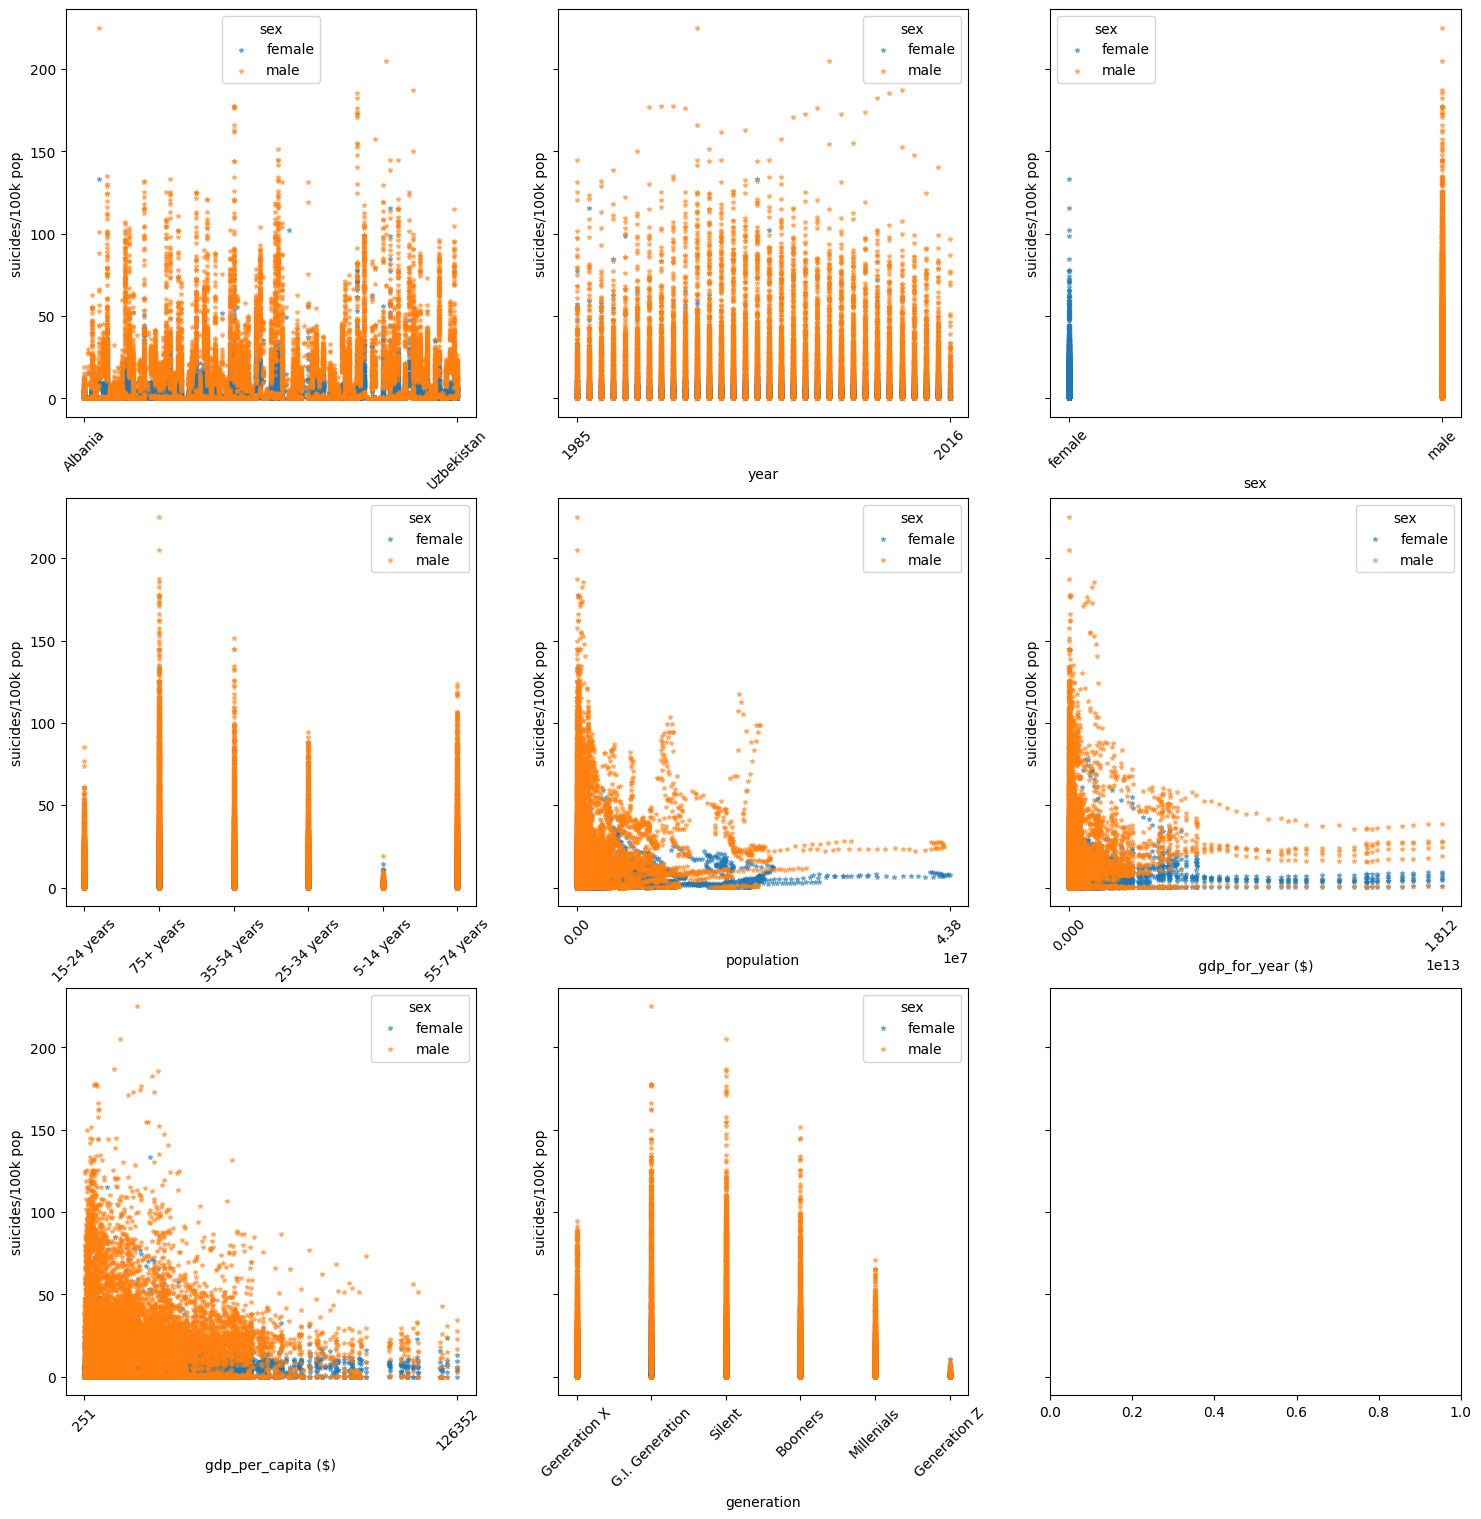

In [11]:
columns_to_plot = df_train.columns[df_train.columns!="suicides/100k pop"]
fig, axs = plt.subplots(3, 3, figsize=(18, 18), sharey=True)

for i,c in enumerate(columns_to_plot):
    x=i%3
    y=i//3
    #axs[y,x].scatter(df_train[c],df_train["suicides/100k pop"],s=5)
    
    for group, data in df_train.groupby('sex'):
        axs[y,x].scatter(data[c],data["suicides/100k pop"],
                        label=group,s=10,alpha=0.5,marker='*')
    axs[y,x].legend(title='sex')

    axs[y,x].set_xlabel(c)
    axs[y,x].set_ylabel("suicides/100k pop")
    if len(df_train[c].unique())>15:
        if df_train[c].dtype == 'object':
            axs[y,x].set_xticklabels([])
        else:
            axs[y,x].set_xticks([df_train[c].min(), df_train[c].max()])
    axs[y,x].tick_params(axis='x', labelrotation=45)


In [12]:
#print the min/max of numerical features and unique values of categorical features
numeric_cols = ['year','population',' gdp_for_year ($) ','gdp_per_capita ($)']
categorical_cols = ['country','sex','age','generation']

for c in numeric_cols:
    print(f'feature:{c} min value: {min(df_train_raw[c])} max value: {max(df_train_raw[c])}')
for c in categorical_cols:
    print(df_train_raw[c].unique())

feature:year min value: 1985 max value: 2016
feature:population min value: 278 max value: 43805214
feature: gdp_for_year ($)  min value: 46919625.0 max value: 18120714000000.0
feature:gdp_per_capita ($) min value: 251 max value: 126352
<StringArray>
[             'Albania',  'Antigua and Barbuda',            'Argentina',
              'Armenia',                'Aruba',            'Australia',
              'Austria',           'Azerbaijan',              'Bahamas',
              'Bahrain',
 ...
             'Thailand',  'Trinidad and Tobago',               'Turkey',
         'Turkmenistan',              'Ukraine', 'United Arab Emirates',
       'United Kingdom',        'United States',              'Uruguay',
           'Uzbekistan']
Length: 101, dtype: str
<StringArray>
['male', 'female']
Length: 2, dtype: str
<StringArray>
['15-24 years', '35-54 years',   '75+ years', '25-34 years', '55-74 years',
  '5-14 years']
Length: 6, dtype: str
<StringArray>
[   'Generation X',          'Silent

From the above scatter plot and print, the nominal features of ['country','sex','age','generation'] might worth some attention.  "age" and "generation" shows some very observable trend with suicide rate. But the feature "generation" needs to be defined more clearly.

With reference to an article from BBC [BBC](https://www.bbc.co.uk/bitesize/articles/zf8j92p), the generation label generally represent the individuals with the following born years:
- G.I. Generation (Greatest Generation): ~1901–1926
- Silent Generation: ~1927–1945
- Baby Boomers (Boomers): ~1946–1964
- Generation X: ~1965–1980
- Millennials (Generation Y): ~1981–1995
- Generation Z: ~1996–2012

Therefore, this feature represent when one was born, which is independent of age feature becase an individual from baby boomer could have commit suicide at a very young age. And an individual with the same age but at different time might have different behavior. As a result, we need to keep all three similar features, namely "age", "year" and "generation".

As for feature "country", there are 101 unique countries and it would mean 100 columnes after one-hot-encoding. But because it is just a name, and unless further transformation is performed to turn a country name to meaningful metrics, like geograhical location, country dependent social factors, it would not give any benefit to include country name for the extra complexity it introduce.


In [13]:
#drop country as well
df_train = df_train_raw.drop(columns=['country-year','HDI for year','suicides_no'])

#separate targets and features
df_train_X = df_train.drop(columns="suicides/100k pop")
df_train_Y = df_train["suicides/100k pop"]

#define the columns that need some handling by types
numeric_cols = ['year','population',' gdp_for_year ($) ','gdp_per_capita ($)']
categorical_cols = ['country','sex','age','generation']

#set up the pipelines for different columns
#No imputation, as there are no NAN and missing values
#Use standardization/one hot encode
numeric_transform = Pipeline([('scaler',StandardScaler())])
cat_transform = Pipeline([('encoder',OneHotEncoder(categories='auto', drop='first'))])

#set up the transformer
preprocessor = ColumnTransformer(transformers=[('numeric',numeric_transform,numeric_cols),('categorical',cat_transform,categorical_cols)],verbose_feature_names_out=False)

df_train_X.head()

,country,year,sex,age,population,gdp_for_year ($),gdp_per_capita ($),generation
0,Albania,1987,male,15-24 years,312900,2.156625e+09,796,Generation X
1,Albania,1987,male,35-54 years,308000,2.156625e+09,796,Silent
2,Albania,1987,female,15-24 years,289700,2.156625e+09,796,Generation X
3,Albania,1987,male,75+ years,21800,2.156625e+09,796,G.I. Generation
4,Albania,1987,male,25-34 years,274300,2.156625e+09,796,Boomers


Below is the metrics for the regression model, with reference to lectures. However, Weighted MAPE are used instead of MAPE because of some 0 results encountered.<br>

In [14]:
#metrics for the regression
def mae(_y, _y_pred):
    return (len(_y)**-1) * np.sum(np.abs(_y_pred-_y))

def mse(_y, _y_pred):
    return (len(_y)**-1) * np.sum((_y_pred-_y)**2)

def wmape(_y, _y_pred):
    return np.sum(np.abs(_y_pred - _y)) / np.sum(np.abs(_y))


### Question1:
####  multiple linear regression model and number of regression coefficients

In [15]:
# 10-fold CV evaluation
def eval_pipeline(pipeline, _X, _y):
    m_scores = [] # MAE    MSE   WMAPE    R2
    kf = KFold(n_splits=10, shuffle=True, random_state=0)
    for train_index, test_index in kf.split(_X, _y):
        pipeline.fit(_X.iloc[train_index], _y.iloc[train_index])
        y_pred = pipeline.predict(_X.iloc[test_index])
        m_scores.append(
                    [mae(_y.iloc[test_index], y_pred),
                     mse(_y.iloc[test_index], y_pred),
                     wmape(_y.iloc[test_index], y_pred),
                     r2_score(_y.iloc[test_index], y_pred)]
                     )
    return np.array(m_scores)

#calculate the CV performance on the whole data set with transform pipeline
_clf = [LinearRegression()]
metric = ['MAE', 'MSE','WMAPE','R2']
CV_result = {}
for c in _clf:
    pipe_lr = make_pipeline(preprocessor,c)
    result = eval_pipeline(pipe_lr,df_train_X,df_train_Y)
    print(f'Model: {c}')
    for i in range(result.shape[1]):
        print(f'{metric[i]}: {result[:,i].mean():.3f}')

Model: LinearRegression()
MAE: 8.663
MSE: 174.270
WMAPE: 0.676
R2: 0.515


In [16]:
# Extract the model and find the number of coefficients
model = pipe_lr.named_steps['linearregression']
print(f"Number of coefficients: {len(model.coef_)}")

# get names of all columns for some are one-hot encoded
feature_names = pipe_lr.named_steps['columntransformer'].get_feature_names_out()
print(f"Total features created: {len(feature_names)}")

Number of coefficients: 115
Total features created: 115


### Question1:

The number of coefficients in this multiple linear regression model is 115. It is because multiple features are categorical/nominal and that they are one-hot-encoded to multiple columns.
|Feature|unique values|encoded columns|
|---|---|---|
|country|101|100|
|sex|2|1|
|age|6|5|
|generation|6|5|

The feature "country" alone was being encoded to 100 columns.
Finally, a 10-fold cross-validation is performed on the multiple linear regression model and yield the following results:
|Metric|Score|
|---|---|
|MAE| 8.663|
|MSE| 174.270|
|WMAPE| 0.676|
|R2| 0.515|

R2 score is 0.515, which is not too impressive.

### Question2:

#### Prediction with  target variable for people aged 20, male, and Generation X

In [17]:
#separate a train test split and retrain
X_train, X_test, y_train, y_test = train_test_split(df_train_X, df_train_Y, test_size=0.2, random_state=0)

# re-Fit the pipeline on the train split
pipe_lr.fit(X_train, y_train)

#create a test target with details:  aged 20, male, and Generation X from the test split

test_target_list =(X_test['year']==1987)&(X_test['sex']=='male')&(X_test['age']=='15-24 years')&(X_test['generation']=='Generation X')
test_target_X = X_test[test_target_list]
test_target_Y = y_test[test_target_list]

y_pred = pipe_lr.predict(test_target_X)
m_scores =[mae(test_target_Y, y_pred),
            mse(test_target_Y, y_pred),
            wmape(test_target_Y, y_pred),
            r2_score(test_target_Y, y_pred)]
print(f'Number of target test size:{len(test_target_Y)}')
for i in range(len(m_scores)):
        print(f'{metric[i]}: {m_scores[i]:.3f}')

Number of target test size:7
MAE: 6.529
MSE: 63.240
WMAPE: 0.561
R2: 0.426


### Question2:

Instead of constructing a list to test, which lack accurate ground truth, the prediction is conducted by separating the orignal dataset into train and test split, training the model with the train split, retrieving a list of target with the required criterias from the test split, and finally the prediction and score are evaluated. The MAE error in this prediction is 6.529, which is smaller than the 10-fold CV MAE, but it might be due to the relatively small target list size of 7. As the R2 statistics get worse than the CV score.

### Question3: 

####  Linear Regression by feature engineer the original nominal age and generation features

In [18]:
#drop country as well
df_train2 = df_train_raw.drop(columns=['country-year','HDI for year','suicides_no'])

#separate targets and features
df_train_X2 = df_train2.drop(columns="suicides/100k pop")
df_train_Y2 = df_train2["suicides/100k pop"]

#mapping for generation and age, according to commonly understood range of born year, take the mean
all_mapping = {
    'generation': {'G.I. Generation':(1901+1926)/2,
                   'Silent':(1927+1945)/2,
                   'Boomers':(1946+1964)/2,
                   'Generation X':(1965+1980)/2,
                   'Millenials':(1981+1995)/2,
                   'Generation Z':(1996+2012)/2},
    'age':{'5-14 years':(5+14)/2,
           '15-24 years':(15+24)/2,
           '25-34 years':(25+34)/2,
           '35-54 years':(35+54)/2, 
           '55-74 years':(55+74)/2,
           '75+ years':(75+100)/2}
}

class FeatureMapper(BaseEstimator, TransformerMixin):
    """
    Define a custom transformer for mapping the generation and age feature for use inside a pipeline
    """
    def __init__(self, mapping_dict):
        self.mapping_dict = mapping_dict

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_transformed = X.copy()
        
        for col, mapping in self.mapping_dict.items():
            if col in X_transformed.columns:
                mapped_series = X_transformed[col].map(mapping)
                X_transformed[col] = mapped_series.fillna(X_transformed[col])
                X_transformed[col] = pd.to_numeric(X_transformed[col], errors='coerce')
        return X_transformed
    
#define the columns that need some handling by types
numeric_cols2 = ['age','generation','year','population',' gdp_for_year ($) ','gdp_per_capita ($)']
categorical_cols2 = ['country','sex']

#set up the pipelines for different columns
#No imputation, as there are no NAN and missing values
#Use mapping for age and generation, standardization/one hot encode for others
numeric_transform2 = Pipeline([('mapper',FeatureMapper(mapping_dict=all_mapping)),('scaler',StandardScaler())])
cat_transform2 = Pipeline([('encoder',OneHotEncoder(categories='auto', drop='first'))])

#set up the transformer
preprocessor2 = ColumnTransformer(transformers=[('numeric',numeric_transform2,numeric_cols2),('categorical',cat_transform2,categorical_cols2)],verbose_feature_names_out=False)


In [19]:
#calculate the CV performance on the whole data set with transform pipeline
_clf2 = [LinearRegression()]
metric2 = ['MAE', 'MSE','WMAPE','R2']
CV_result = {}
for c in _clf2:
    pipe_lr2 = make_pipeline(preprocessor2,c)
    result2 = eval_pipeline(pipe_lr2,df_train_X2,df_train_Y2)
    print(f'Model: {c}')
    for i in range(result2.shape[1]):
        print(f'{metric2[i]}: {result2[:,i].mean():.3f}')

Model: LinearRegression()
MAE: 8.927
MSE: 179.982
WMAPE: 0.697
R2: 0.499


In [20]:
# Extract the model and find the number of coefficients
model2 = pipe_lr2.named_steps['linearregression']
print(f"Number of coefficients: {len(model2.coef_)}")


Number of coefficients: 107


### Question3:

The number of coefficients in this second multiple linear regression model is 107. It is because the country and sex feature are still one-hot-encoded to multiple columns. But Age and generation are now single column numeric features.
|Feature|unique values|encoded columns|
|---|---|---|
|country|101|100|
|sex|2|1|

Finally, a 10-fold cross-validation is performed on the multiple linear regression model and yield the following results:
|Metric|Score|
|---|---|
|MAE| 8.927|
|MSE| 179.982|
|WMAPE| 0.697|
|R2| 0.499|

R2 score is 0.499, which is worse than the one-hot-encoded version.

### Question4:

#### Prediction with target variable for people aged 20, male, and Generation X with Q3 model

In [21]:
#Use the same train test split from Question 2
# re-Fit the pipeline on the train split
pipe_lr2.fit(X_train, y_train)

#use the same target list from Question 2 with details:  aged 20, male, and Generation X from the test split

y_pred2 = pipe_lr2.predict(test_target_X)
m_scores2 =[mae(test_target_Y, y_pred2),
            mse(test_target_Y, y_pred2),
            wmape(test_target_Y, y_pred2),
            r2_score(test_target_Y, y_pred2)]
print(f'Number of target test size:{len(test_target_Y)}')
for i in range(len(m_scores2)):
        print(f'{metric2[i]}: {m_scores2[i]:.3f}')

Number of target test size:7
MAE: 6.063
MSE: 57.951
WMAPE: 0.521
R2: 0.474


### Question4:

Using the same train test split from question 2, and the same list of target with the required criterias from the test split, and finally the prediction and scores are evaluated. The MAE error in this prediction by Q3 model is 6.063 and the R2 score is 0.474.

### Question5:

Summary of performance of the model in Question 2 and 4:
|Metrics|LinearRegression with one-hot-encoded age and generation|LinearRegression with engineered numerical age and generation|
|---|---|---|
|MAE| 6.529|6.063|
|MSE| 63.240|57.951|
|WMAPE| 0.561|0.521|
|R2| 0.426| 0.474|

As shown on above table, the performance of Q3 model is better than Q1 model. MAE error is smaller, as well as R2 statistics, MSE and WMAPE, with about 10% improvement.


### Question6:

#### Prediction with target variable for people aged 33, male, and Generation Alpha

Generation Alpha corresponds to the group that were born after Gen Z, roughly around 2012 to 2025. As there is no gen alpha data inside the dataset, a hypothetical test case is made up with as reasonable estimate as possible.

In [23]:
#create the single gen alpha data
target_data = {
    'country': ['United States'],    
    'year': [2025],
    'sex': ['male'],
    'age': [7],
    'population': [24000000],
    ' gdp_for_year ($) ': [31000000000000],
    'gdp_per_capita ($)': [94000],
    'generation':[2017]
}
target_df = pd.DataFrame(target_data)

y_pred_single = pipe_lr2.predict(target_df)
print(target_df)
print(f'Predicted suicide rate:{y_pred_single}')


         country  year   sex  age  population   gdp_for_year ($)   \
0  United States  2025  male    7    24000000      31000000000000   

   gdp_per_capita ($)  generation  
0               94000        2017  
Predicted suicide rate:[7.91683126]


### Question6:
For a target of Gen Alpha, I use a data of a United States Male born in the median of the range of 2012-2025, together with the estimated population of Gen Alpha male and GDP data, the predicted suicide rate is 7.91, 

### Question7:

####  advantage when using regression (as opposed to classification with nominal features) in terms of independent variables

One biggest advantage of using regression is that it could preserve the continuous nature of variables. Classification, in contrast, force a continuous numerical feature into nominal clusters by binning them. That would destroy some valuable information like variance and magnitude of the data. Regression maintain that part of information by keeping the continuity of data, and therefore help to produce a more precise model for relationship between target and feature variable.

### Question8:

####   advantage when using regular numerical values rather than one-hot encoding for regression. 

One advantage of using regular numerical values instead of one-hot encoding in regression is that it condense an otherwise sparse, multi-column one-hot-encoded feature to a single column, avoiding the problem of curse of dimensionality, producing a less complex and more efficient model. Additionally, for feature like 'generation', a numerical value preserves the inherent ordinal relationship between generations, which one-hot encoding would completely destroys.

### Question9:

For this particular dataset and workload, I would recommend a regression model because of the following reason:
1. The prediction, suicide rate, is continous in nature, which means regression naturally fit.
2. The regression model would produce a coefficient for each features, which can be used to explain how each feature/factor would affect suicide rate when they change, which could be very useful for reporting/policy making.
